In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

## Custom Imports

In [3]:
import utils

from custom_estimators import (
    FFTRepresentation,
    PCAOutlierDetector,
    PCAMahalanobisOutlierDetector
)

from plotting import (
    plot_selected_outliers,
    plot_outlier_scores
)

from params import SimulationParameters

## Simulation Parameters

In [4]:
params = SimulationParameters(
    amplitudes=[25, 27, 30, 56, 72],
    frequencies=[12, 15, 20, 25, 30],
    frame_rate=1000,
    noise_level=1000,
    noise_stdev=100,
    n_signals=200,
    contamination=0.1,
    a=1,
    b=3,
    n_components=35,
    n_simulations=500
)

## Simulation

In [5]:
pca_metrics = {
    "PCA": [],
    "PCA_MAHAL": [],
    "FFT_PCA_MAHAL": [],
}

lof_metrics = {
    "LOF": [],
    "FFT_LOF": [],
    "PCA_LOF": [],
}


for seed in range(params.n_simulations):

    utils.seed_everything(seed)

    base_signal, noisy_signals, ground_truth = utils.simulate_signals(params)

    pca_mahal = PCAMahalanobisOutlierDetector(random_state=42, n_components=params.n_components)
    pca_mahal_pred = pca_mahal.fit_predict(noisy_signals)

    pca_pred = PCAOutlierDetector().fit_predict(noisy_signals)

    fft_pca = make_pipeline(
        FFTRepresentation(n_components=params.n_components),
        PCAMahalanobisOutlierDetector(random_state=42, n_components=2)
    )
    fft_pred = fft_pca.fit_predict(noisy_signals)

    pca_metrics["PCA"].append(f1_score(ground_truth, pca_pred, pos_label=-1))
    pca_metrics["PCA_MAHAL"].append(f1_score(ground_truth, pca_mahal_pred, pos_label=-1))
    pca_metrics["FFT_PCA_MAHAL"].append(f1_score(ground_truth, fft_pred, pos_label=-1))

    lof = make_pipeline(
        StandardScaler(),
        LocalOutlierFactor(contamination=params.contamination)
    )
    lof_pred = lof.fit_predict(noisy_signals)

    fft_lof = make_pipeline(
        FFTRepresentation(n_components=params.n_components),
        StandardScaler(),
        LocalOutlierFactor(contamination=params.contamination)
    )
    fft_pred = fft_lof.fit_predict(noisy_signals)

    pca_lof = make_pipeline(
        PCA(n_components=params.n_components, random_state=42),
        LocalOutlierFactor(contamination=params.contamination)
    )
    pca_pred = pca_lof.fit_predict(noisy_signals)
    
    lof_metrics["LOF"].append(f1_score(ground_truth, lof_pred, pos_label=-1))
    lof_metrics["FFT_LOF"].append(f1_score(ground_truth, fft_pred, pos_label=-1))
    lof_metrics["PCA_LOF"].append(f1_score(ground_truth, pca_pred, pos_label=-1))

## Results

### LOF vs PCA + LOF vs FFT + LOF

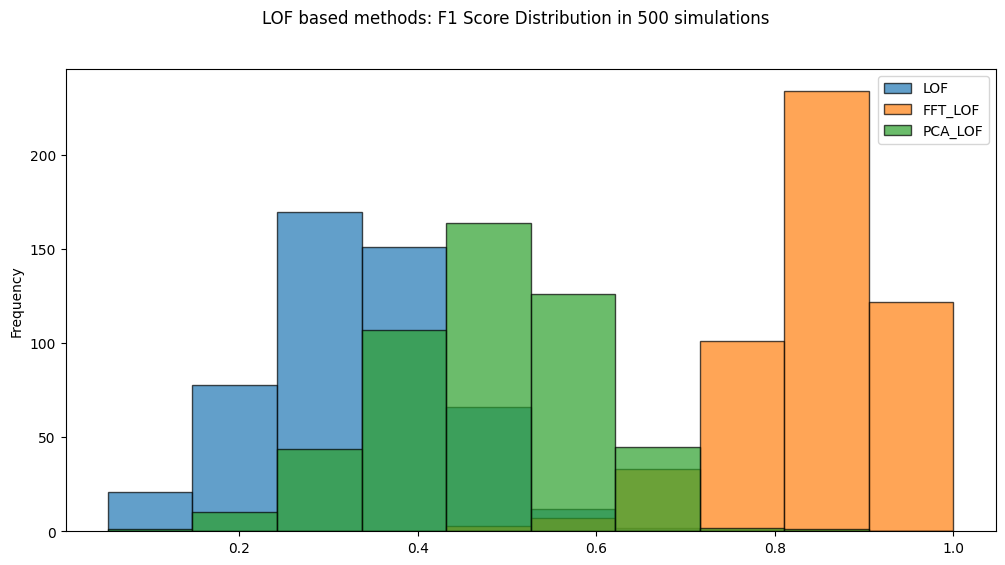

In [6]:
lof_metrics_df = pd.DataFrame(lof_metrics)
lof_metrics_df.plot(kind="hist", alpha=0.7, figsize=(12, 6), edgecolor="black")
plt.suptitle("LOF based methods: F1 Score Distribution in 500 simulations")
plt.savefig("img/pca-lof-vs-fft-lof-chart.png")
plt.show()

### PCA + Mahalanobis vs FFT + PCA + Mahalanobis

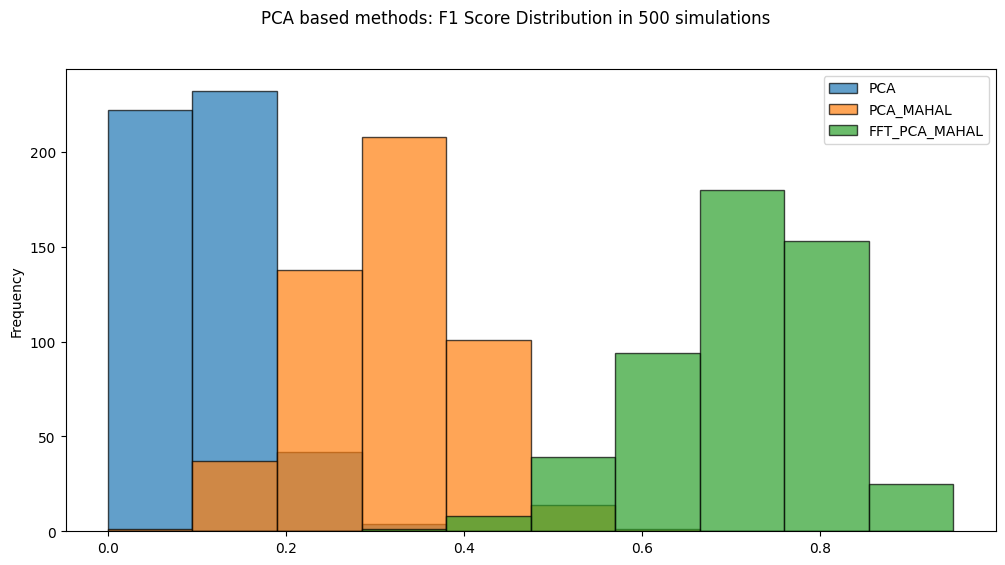

In [7]:
pca_metrics_df = pd.DataFrame(pca_metrics)
pca_metrics_df.plot(kind="hist", alpha=0.7, figsize=(12, 6), edgecolor="black")
plt.suptitle("PCA based methods: F1 Score Distribution in 500 simulations")
plt.savefig("img/pca-mahal-vs-fft-pca-mahal-chart.png")
plt.show()

## Picking a single simulation

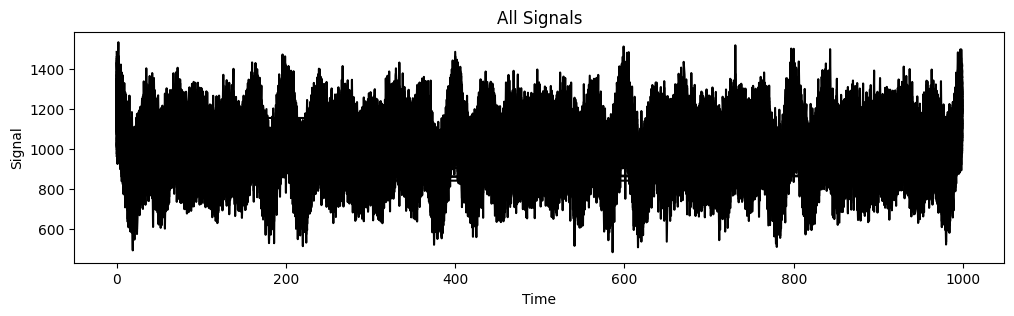

In [8]:
utils.seed_everything(42)

base_signal, noisy_signals, ground_truth = utils.simulate_signals(params)

plt.figure(figsize=(12, 3))
plt.plot(noisy_signals.T, color="black");
plt.title("All Signals")
plt.ylabel("Signal")
plt.xlabel("Time")
plt.savefig("img/all-signals-chart.png")
plt.show()

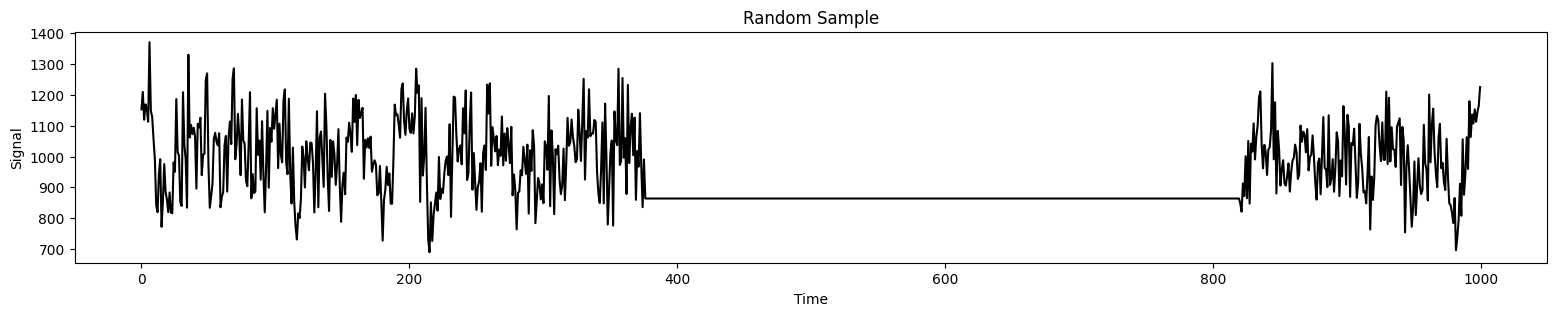

In [9]:
rng = np.random.default_rng(12332)
plt.figure(figsize=(19, 3))
plt.plot(noisy_signals.T[:, rng.integers(0, len(noisy_signals),1)], color="black");
plt.title("Random Sample")
plt.ylabel("Signal")
plt.xlabel("Time")
plt.savefig("img/random-sample-chart.png")
plt.show()

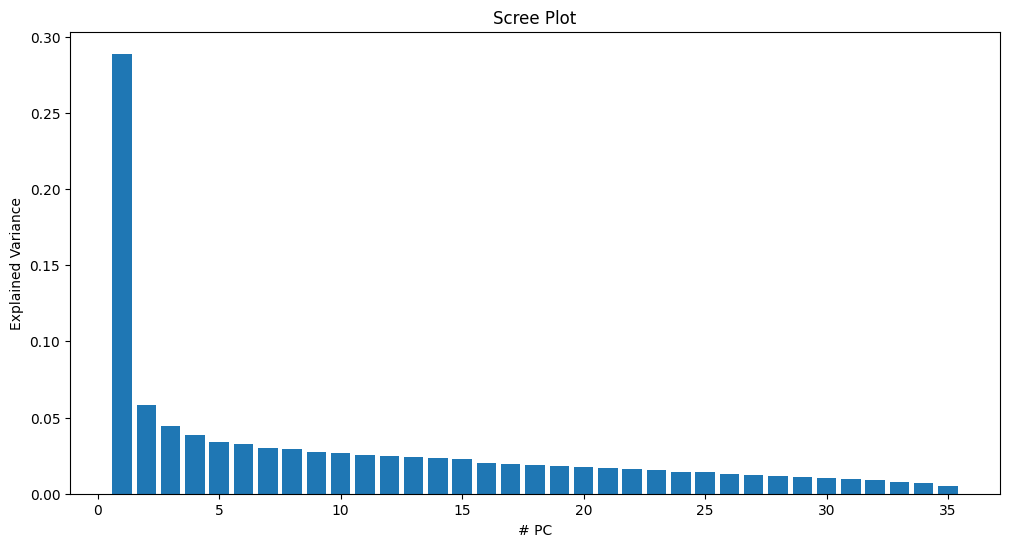

In [10]:
pca_mahal = make_pipeline(
    FFTRepresentation(n_components=params.n_components),
    PCAMahalanobisOutlierDetector(random_state=42, n_components=params.n_components)
)
pca_mahal = pca_mahal.fit(noisy_signals)

explained_var = (
    pca_mahal
    .named_steps["pcamahalanobisoutlierdetector"]
    .pipeline_
    .named_steps["pca"]
    .explained_variance_ratio_
)

plt.figure(figsize=(12, 6))
plt.bar(range(1, len(explained_var) + 1), explained_var)
plt.title("Scree Plot")
plt.ylabel("Explained Variance")
plt.xlabel("# PC")
plt.savefig("img/scree-chart.png")
plt.show()

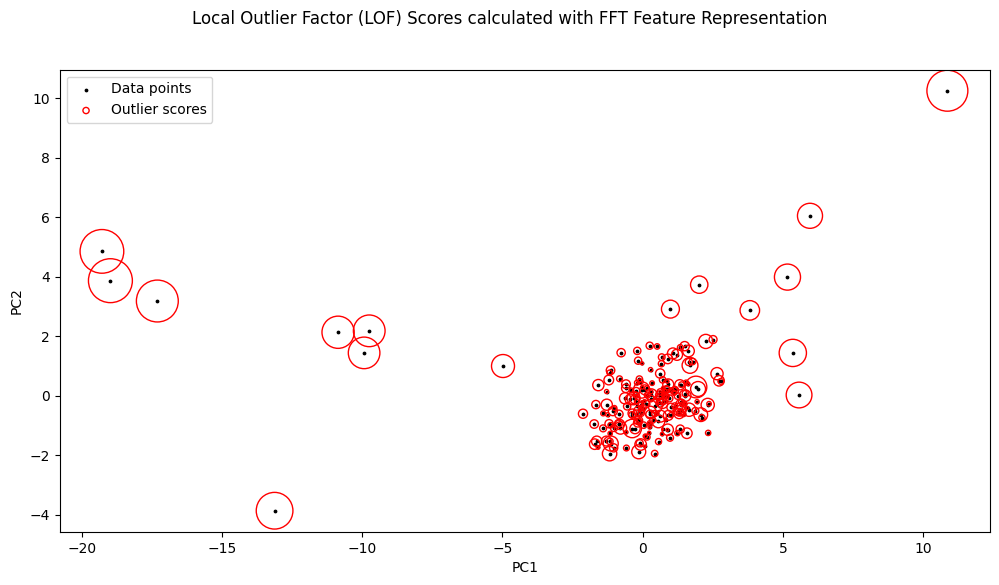

In [11]:
pca_mahal = make_pipeline(
    FFTRepresentation(n_components=params.n_components),
    PCAMahalanobisOutlierDetector(random_state=42, n_components=2)
)
pca_mahal = pca_mahal.fit(noisy_signals)

lof = make_pipeline(
    FFTRepresentation(n_components=params.n_components),
    StandardScaler(),
    LocalOutlierFactor(contamination=params.contamination)
)
y_pred = lof.fit_predict(noisy_signals)

lof_scores = lof.named_steps["localoutlierfactor"].negative_outlier_factor_

components = pca_mahal.named_steps["pcamahalanobisoutlierdetector"].components_
data = pd.DataFrame(components, columns=["PC1", "PC2"]).assign(score=lof_scores)

plot_outlier_scores(data)
plt.savefig("img/outliers-score-chart.png")
plt.show()

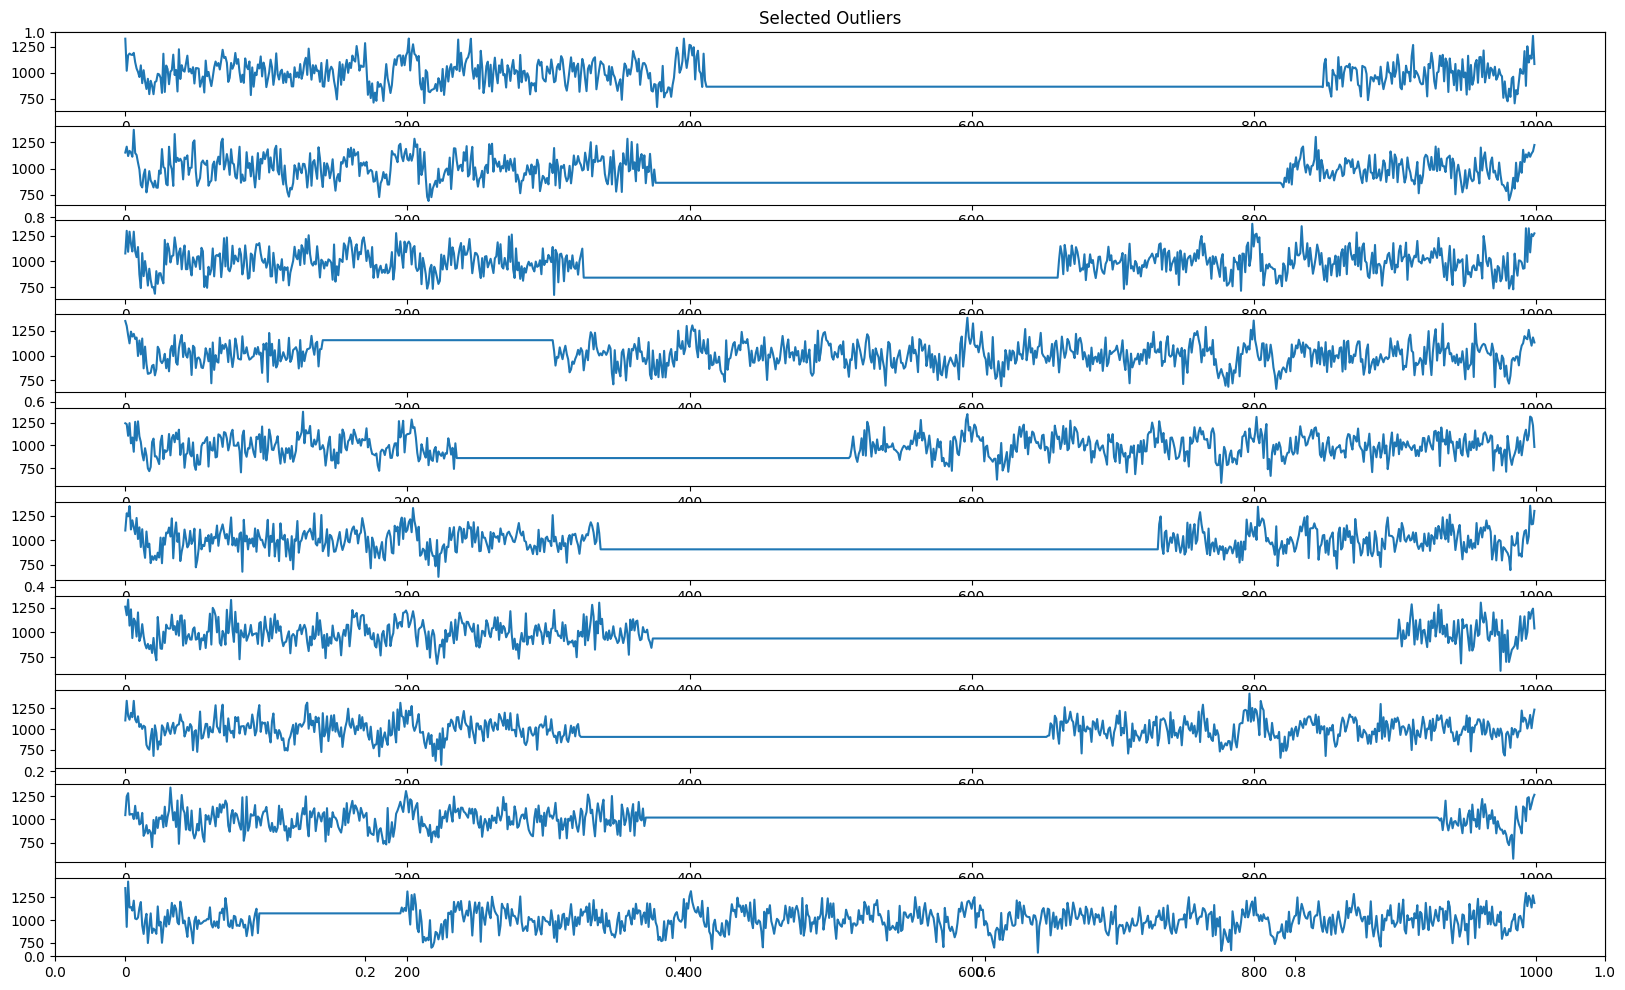

In [12]:
plot_selected_outliers(noisy_signals, lof_scores, params.contamination)
plt.savefig("img/outliers-chart.png")
plt.show()